In [2]:
# 1단계: T4 GPU 설정 및 환경 준비
# 1. GPU가 잘 켜졌는지 확인
import torch
if torch.cuda.is_available():
    print(f"✅ T4 GPU 연결 성공! (장치명: {torch.cuda.get_device_name(0)})")
else:
    print("⚠️ GPU가 안 켜졌어요! [런타임] 설정을 다시 확인해주세요.")

# 2. 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# 3. 필수 라이브러리 설치
!pip install nibabel

# 4. 공통 라이브러리 불러오기
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from glob import glob
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

✅ T4 GPU 연결 성공! (장치명: Tesla T4)
Mounted at /content/drive


✅ 파일을 찾았습니다! 로딩 중...
데이터 크기: (240, 240, 155)


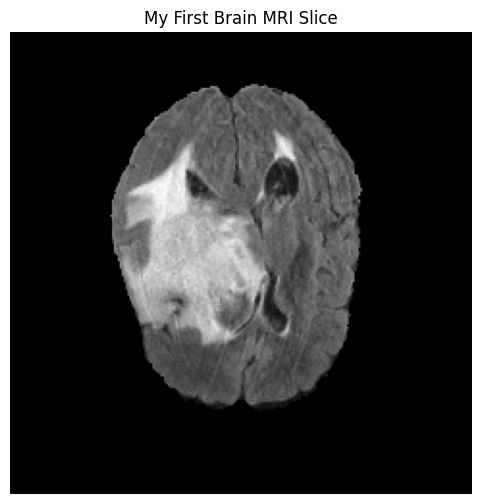

In [3]:
# 2단계: MRI 사진 눈으로 확인하기 (시각화)
import os
import nibabel as nib
import matplotlib.pyplot as plt

# 1. 파일 경로 설정 (아까 만든 폴더 구조대로 적었습니다)
# 파일명 끝에 'flair.nii'가 붙은 것을 가져옵니다.
file_path = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/MRI(데이터셋)/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii'

# 2. 파일이 진짜 있는지 확인
if os.path.exists(file_path):
    print("✅ 파일을 찾았습니다! 로딩 중...")

    # 3. 파일 불러오기
    img = nib.load(file_path)
    data = img.get_fdata()

    print(f"데이터 크기: {data.shape}")
    # 보통 (240, 240, 155) -> (가로, 세로, 높이/장수)

    # 4. 정중앙 슬라이스 보기
    # 155장 중 가운데인 77번째 장을 꺼내봅니다.
    mid_slice = data[:, :, 77]

    # 5. 그림 그리기
    plt.figure(figsize=(6, 6))
    plt.imshow(mid_slice.T, cmap='gray', origin='lower') # .T는 회전, gray는 흑백
    plt.title("My First Brain MRI Slice")
    plt.axis('off') # 눈금 끄기
    plt.show()

else:
    print("❌ 파일을 못 찾겠어요. 구글 드라이브 폴더 이름이나 경로를 다시 확인해주세요!")

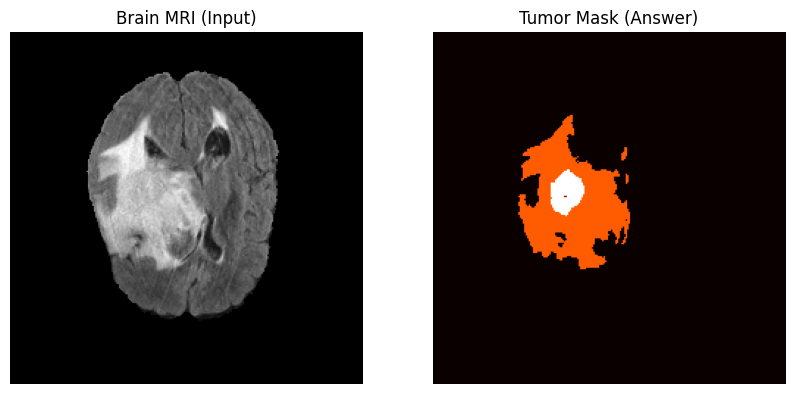

정답지에 있는 숫자들 종류: [0. 1. 2. 4.]


In [4]:
# 3단계: "정답지" 확인하기 (Mask 시각화)
import nibabel as nib
import matplotlib.pyplot as plt

# 1. 파일 경로 설정
# 아까와 같은 폴더입니다. 파일 이름만 다릅니다.
base_path = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/MRI(데이터셋)/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001'
image_path = base_path + '_flair.nii'  # 문제 (뇌 사진)
mask_path  = base_path + '_seg.nii'    # 정답 (종양 위치)

# 2. 불러오기
img_data  = nib.load(image_path).get_fdata()
mask_data = nib.load(mask_path).get_fdata()

# 3. 같은 위치(중간 층) 잘라서 꺼내기
slice_num = 77  # 77번째 장을 꺼냅니다
img_slice  = img_data[:, :, slice_num]
mask_slice = mask_data[:, :, slice_num]

# 4. 나란히 그려보기
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 왼쪽: 뇌 사진
ax[0].imshow(img_slice.T, cmap='gray', origin='lower')
ax[0].set_title('Brain MRI (Input)')
ax[0].axis('off')

# 오른쪽: 정답지 (종양)
# 종양이 잘 보이게 'hot' (붉은색 계열) 색상을 썼습니다.
ax[1].imshow(mask_slice.T, cmap='hot', origin='lower')
ax[1].set_title('Tumor Mask (Answer)')
ax[1].axis('off')

plt.show()

# 5. 종양 값이 어떻게 생겼는지 숫자로 찍어보기
import numpy as np
print(f"정답지에 있는 숫자들 종류: {np.unique(mask_slice)}")

=== 변환 전 (원본) ===
최소값: 0.0
최대값: 625.0

=== 변환 후 (정규화) ===
최소값: 0.0
최대값: 1.0


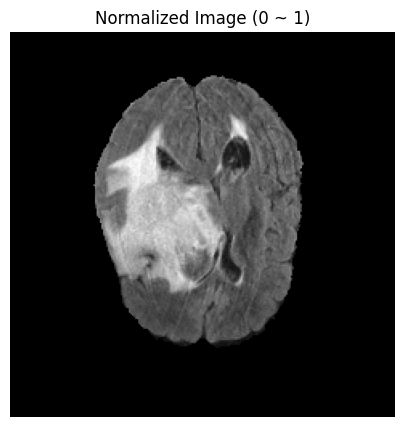

In [5]:
# 4단계: 숫자 예쁘게 맞추기 (정규화, Normalization)
import numpy as np

# 1. 정규화 함수 만들기 (Min-Max Scaling)
# 공식: (내 점수 - 최하점) / (최고점 - 최하점)
# 이렇게 하면 무조건 0~1 사이 점수가 됩니다.
def normalize_image(volume):
    min_val = volume.min()
    max_val = volume.max()

    if max_val - min_val == 0: # 모든 값이 0인 경우 방지
        return volume

    return (volume - min_val) / (max_val - min_val)

# 2. 정규화 적용하기
# 아까 불러온 뇌 사진(img_data)을 변환합니다.
img_normalized = normalize_image(img_data)

# 3. 결과 비교해보기
print("=== 변환 전 (원본) ===")
print(f"최소값: {img_data.min()}")
print(f"최대값: {img_data.max()}") # 보통 수백~수천 단위

print("\n=== 변환 후 (정규화) ===")
print(f"최소값: {img_normalized.min()}")
print(f"최대값: {img_normalized.max()}") # 무조건 1.0이 나와야 함

# 4. 눈으로 확인 (그림은 똑같아 보여야 정상입니다)
# 숫자의 '크기'만 줄였지 '비율'은 그대로니까요.
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.imshow(img_normalized[:, :, 77].T, cmap='gray', origin='lower')
plt.title("Normalized Image (0 ~ 1)")
plt.axis('off')
plt.show()

In [6]:
# 5단계: "식빵 자르기" (Slicing & Saving)
import os
import numpy as np

# 1. 저장할 폴더 만들기 (처리데이터 폴더)
# 구글 드라이브에 '처리데이터'라는 폴더를 새로 만듭니다.
save_dir = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/처리데이터'
os.makedirs(f"{save_dir}/images(뇌 사진)", exist_ok=True) # 뇌 사진 저장소
os.makedirs(f"{save_dir}/masks(정답지)", exist_ok=True)  # 정답지 저장소

print(f"📂 저장 경로 생성 완료: {save_dir}")

# 2. 자르고 저장하는 함수
def save_slices(image, mask, volume_name):
    # image: 3D 뇌 데이터 (정규화 완료된 것)
    # mask: 3D 정답 데이터

    cnt = 0 # 저장된 장수 카운트

    # 전체 높이(보통 155장)만큼 반복
    for i in range(image.shape[2]):

        # 한 장 꺼내기
        img_slice = image[:, :, i]
        mask_slice = mask[:, :, i]

        # [중요] 아무 정보 없는 검은색 배경만 있는 장은 버립니다.
        # 학습에 도움이 안 되니까요. (최대값이 0보다 클 때만 저장)
        if img_slice.max() > 0 and mask_slice.max() > 0:

            # 파일명 만들기 (예: BraTS_001_slice_77.npy)
            file_name = f"{volume_name}_slice_{i:03d}.npy"

            # .npy 포맷(파이썬 전용 고속 파일)으로 저장
            np.save(f"{save_dir}/images(뇌 사진)/{file_name}", img_slice)
            np.save(f"{save_dir}/masks(정답지)/{file_name}", mask_slice)

            cnt += 1

    print(f"✅ {cnt}장의 슬라이스가 저장되었습니다! (빈 배경은 제외함)")

# 3. 실행하기 (아까 만든 img_normalized와 mask_data를 사용)
# volume_name은 파일 구분을 위한 이름표입니다.
save_slices(img_normalized, mask_data, "BraTS_Training_001")

📂 저장 경로 생성 완료: /content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/처리데이터
✅ 83장의 슬라이스가 저장되었습니다! (빈 배경은 제외함)


In [7]:
# 6단계: "배달 기사님 부르기" (PyTorch Dataset & DataLoader)
import torch
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
from glob import glob

# 1. 데이터셋 클래스 만들기 (배달 기사님 메뉴얼)
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir):
        # 저장된 파일들의 목록을 다 가져옵니다.
        self.image_files = sorted(glob(os.path.join(root_dir, 'images(뇌 사진)', '*.npy')))
        self.mask_files  = sorted(glob(os.path.join(root_dir, 'masks(정답지)', '*.npy')))

        # 파일이 없는 경우 명확한 에러 메시지 출력
        if not self.image_files:
            raise RuntimeError(
                f"오류: 이미지 파일(.npy)을 '{os.path.join(root_dir, 'images(뇌 사진)')}' 경로에서 찾을 수 없습니다.\n"
                "'6단계: \"식빵 자르기\" (Slicing & Saving)' 셀이 성공적으로 실행되어 \n"
                "데이터가 생성되었는지 확인해 주세요."
            )

    def __len__(self):
        # 데이터가 총 몇 개인지 알려줍니다.
        return len(self.image_files)

    def __getitem__(self, idx):
        # idx번째 데이터를 꺼내서 포장합니다.

        # 1. 파일 로드
        img_path = self.image_files[idx]
        mask_path = self.mask_files[idx]

        image = np.load(img_path)
        mask = np.load(mask_path)

        # 2. 차원 추가하기 (중요!)
        # 모델은 (채널, 가로, 세로) 순서를 원합니다.
        # 현재: (240, 240) -> 변경: (1, 240, 240)
        image = image[np.newaxis, :, :]
        mask = mask[np.newaxis, :, :]

        # 3. 텐서(Tensor)로 변환
        # 파이토치는 numpy 대신 tensor를 씁니다.
        return torch.from_numpy(image).float(), torch.from_numpy(mask).float()

# --- 테스트 실행 ---

# 2. 데이터셋 생성
data_dir = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/처리데이터'
dataset = BrainTumorDataset(data_dir)

# 3. 배달 기사(DataLoader) 생성
# batch_size=16 : 한 번에 16장씩 배달해라
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# 4. 잘 나오는지 확인 (첫 번째 배달만 받아보기)
images, masks = next(iter(loader))

print(f"총 데이터 개수: {len(dataset)}장")
print(f"배달된 이미지 묶음 크기: {images.shape}")
print(f"배달된 정답지 묶음 크기: {masks.shape}")

총 데이터 개수: 83장
배달된 이미지 묶음 크기: torch.Size([16, 1, 240, 240])
배달된 정답지 묶음 크기: torch.Size([16, 1, 240, 240])


In [8]:
# 7단계: "뇌를 그리는 화가" (U-Net 모델 만들기)
import torch
import torch.nn as nn

# 1. 블럭 만들기 (반복되는 부품)
# 컨볼루션(Conv) 2번 + 활성화 함수(ReLU) 2번
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            # padding=1을 줘야 이미지 크기가 줄어들지 않습니다.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), # 학습 잘 되게 돕는 장치
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

# 2. U-Net 전체 조립하기
class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1):
        super(UNet, self).__init__()

        # --- 내려가는 길 (Encoder) ---
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = DoubleConv(64, 128)
        self.down2 = DoubleConv(128, 256)
        self.down3 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2) # 반으로 줄이기

        # --- 바닥 (Bottleneck) ---
        self.bot = DoubleConv(512, 1024)

        # --- 올라가는 길 (Decoder) ---
        # UpConv: 이미지를 2배로 늘려줍니다.
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(1024, 512) # 합쳐진 채널 수 주의 (512+512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(128, 64)

        # --- 마지막 출력 ---
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # 1. 내려가기 (특징 추출)
        x1 = self.inc(x)
        x2 = self.down1(self.pool(x1))
        x3 = self.down2(self.pool(x2))
        x4 = self.down3(self.pool(x3))

        # 2. 바닥 찍기
        x5 = self.bot(self.pool(x4))

        # 3. 올라가기 (복원 + 합치기)
        # torch.cat이 바로 'Skip Connection' 입니다.

        x = self.up1(x5)
        # 크기 차이 발생시 보정 (생략 가능하나 안전을 위해)
        # 여기서는 padding=1을 썼으므로 크기가 딱 맞아서 바로 합칩니다.
        x = torch.cat([x4, x], dim=1)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.dec2(x)

        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.dec3(x)

        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.dec4(x)

        # 4. 결과
        return self.outc(x)

# --- 모델 테스트 ---
# 가짜 데이터를 넣어서 에러가 안 나는지 확인합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels=1, n_classes=1).to(device)

# 아까 만든 배달 기사에게서 받은 데이터 16장 넣어보기
# images는 위에서 받아둔 변수입니다.
output = model(images.to(device))

print(f"입력 크기: {images.shape}")
print(f"출력 크기: {output.shape}")

입력 크기: torch.Size([16, 1, 240, 240])
출력 크기: torch.Size([16, 1, 240, 240])


In [9]:
# 8단계 채점 기준표 만들기 (Dice Loss & Optimizer)
# 1. Dice Loss (겹치는 정도를 계산하는 채점표)
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # 1. 모델의 예측값을 0~1 사이로 만듭니다 (Sigmoid)
        inputs = torch.sigmoid(inputs)

        # 2. 1줄로 쭉 폅니다 (계산하기 쉽게)
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        # 3. 겹치는 부분 계산 (교집합)
        intersection = (inputs * targets).sum()

        # 4. Dice 공식: (2 * 교집합) / (내꺼 + 정답지)
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

        # 5. Loss는 '틀린 정도'니까 1에서 뺍니다.
        return 1 - dice

# 2. 준비물 세팅
criterion = DiceLoss() # 채점관
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) # 선생님 (학습률 0.0001)

print("✅ 채점 기준표(Dice Loss)와 선생님(Adam) 준비 완료!")

✅ 채점 기준표(Dice Loss)와 선생님(Adam) 준비 완료!


In [10]:
# 9단계: 학습 시작! (Training Loop)
# === 1. GPU 장치 설정 (가장 중요!) ===
# GPU가 켜져 있으면 'cuda', 아니면 'cpu'를 잡습니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"현재 사용 중인 장치: {device}")
if str(device) == 'cuda':
    print("✅ GPU 가속이 활성화되었습니다! (학습 속도가 빨라집니다)")
else:
    print("⚠️ GPU가 꺼져 있습니다. [런타임] -> [런타임 유형 변경]에서 T4 GPU를 선택하세요.")

# === 2. 모델과 데이터 준비 ===
# 모델을 만들고 GPU로 이사시킵니다(.to(device))
model = UNet(n_channels=1, n_classes=1).to(device)

# 채점표와 선생님 준비
criterion = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 데이터 로더 다시 준비 (경로는 그대로)
data_dir = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/처리데이터'
dataset = BrainTumorDataset(data_dir)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# === 3. 학습 시작 ===
num_epochs = 10
loss_history = []

print("\n🚀 GPU 학습 시작!")
print("-" * 50)

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0

    for images, masks in loader:
        # [핵심] 데이터도 GPU로 보내야 합니다!
        # 여기서 에러가 제일 많이 납니다.
        images = images.to(device)
        masks = masks.to(device)

        # 순전파
        outputs = model(images)
        loss = criterion(outputs, masks)

        # 역전파
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}")

print("-" * 50)
print("🏁 학습 완료!")

현재 사용 중인 장치: cuda
✅ GPU 가속이 활성화되었습니다! (학습 속도가 빨라집니다)

🚀 GPU 학습 시작!
--------------------------------------------------
Epoch [1/10]  Loss: 0.7199
Epoch [2/10]  Loss: 0.6051
Epoch [3/10]  Loss: 0.6017
Epoch [4/10]  Loss: 0.5732
Epoch [5/10]  Loss: 0.5265
Epoch [6/10]  Loss: 0.5167
Epoch [7/10]  Loss: 0.4959
Epoch [8/10]  Loss: 0.5015
Epoch [9/10]  Loss: 0.5033
Epoch [10/10]  Loss: 0.4737
--------------------------------------------------
🏁 학습 완료!


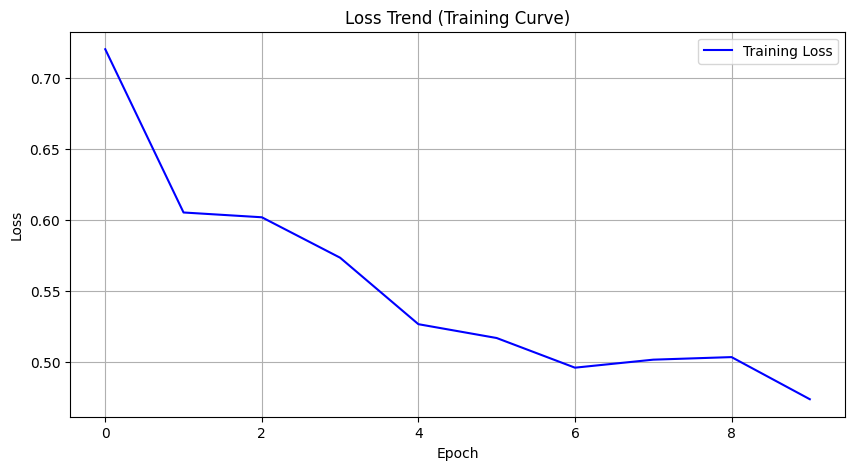

✅ 학습 그래프가 구글 드라이브에 저장되었습니다: loss_graph(손실).png


In [11]:
# 1단계: 학습 결과 그래프 그리기 (증거 자료)
import matplotlib.pyplot as plt

# 학습 과정 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='blue')
plt.title('Loss Trend (Training Curve)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/loss_graph(손실).png') # 이미지로 저장
plt.show()

print("✅ 학습 그래프가 구글 드라이브에 저장되었습니다: loss_graph(손실).png")

In [12]:
# 2단계: 모델 저장하기 (가장 중요!)
# 모델 저장 경로
model_save_path = '/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/unet_brain_tumor.pth'

# 저장하기 (모델의 '기억'만 저장하는 방식)
torch.save(model.state_dict(), model_save_path)

print(f"✅ 모델 저장이 완료되었습니다! 경로: {model_save_path}")
print("이제 코랩을 꺼도 모델은 안전합니다.")

✅ 모델 저장이 완료되었습니다! 경로: /content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/unet_brain_tumor.pth
이제 코랩을 꺼도 모델은 안전합니다.


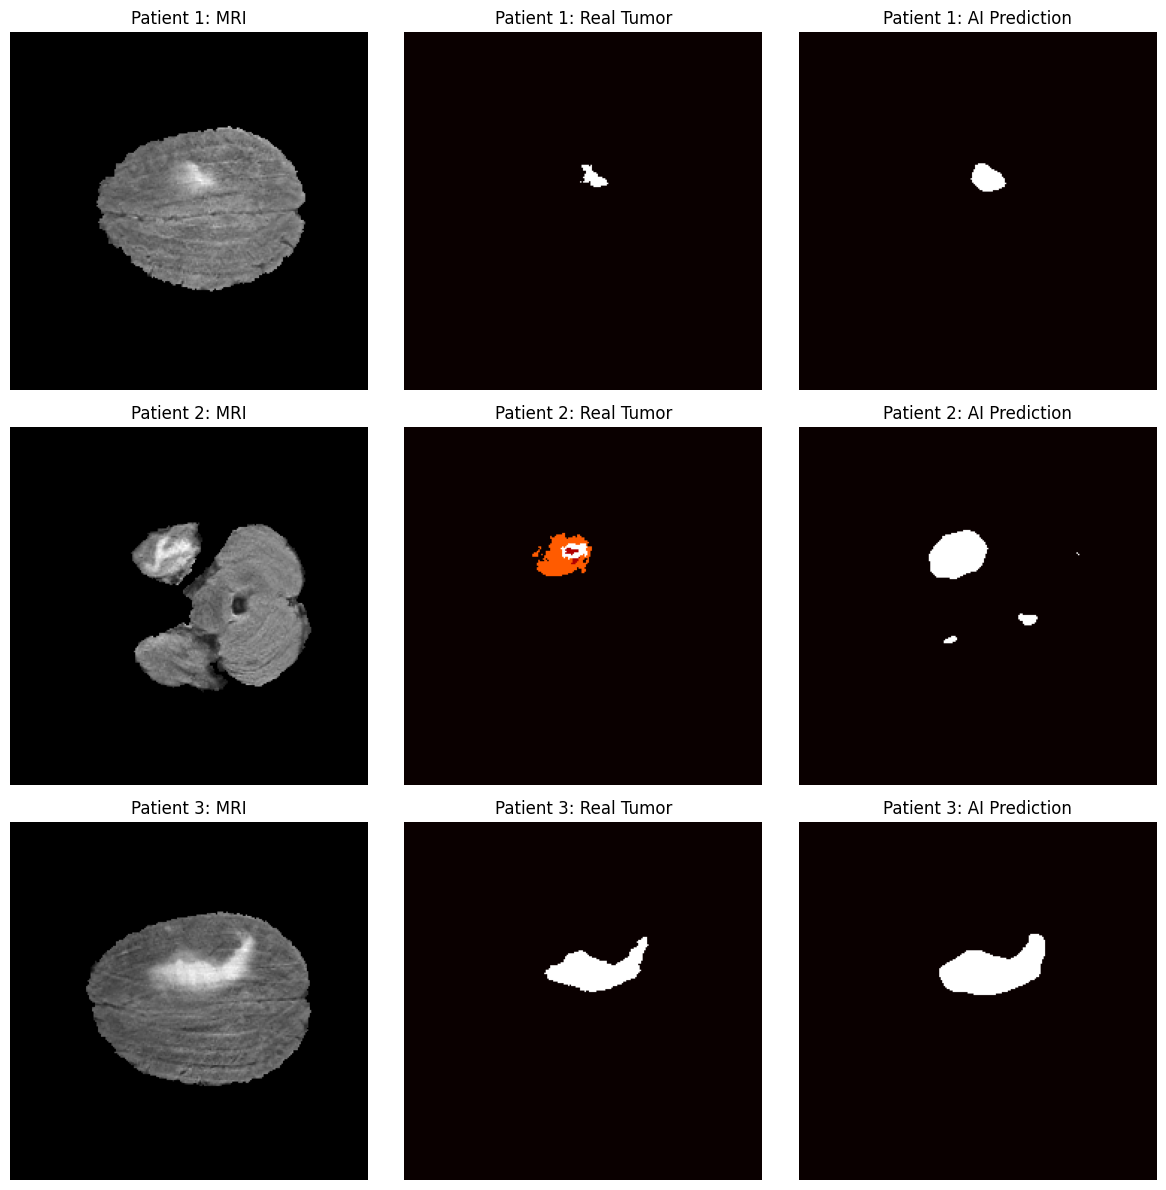

In [13]:
# 결과 눈으로 확인하기 (최종 점검)
model.eval() # 평가 모드

# 테스트용 데이터 몇 개 가져오기
test_loader = DataLoader(dataset, batch_size=3, shuffle=True)
imgs, masks = next(iter(test_loader))
imgs = imgs.to(device)

# 예측하기
with torch.no_grad():
    preds = model(imgs)
    preds = (torch.sigmoid(preds) > 0.5).float() # 0.5 기준으로 0과 1로 나눔

# 결과 그리기 (3줄)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
plt.gray()

for i in range(3):
    # 원본
    axes[i, 0].imshow(imgs[i][0].cpu())
    axes[i, 0].set_title(f'Patient {i+1}: MRI')
    axes[i, 0].axis('off')

    # 정답
    axes[i, 1].imshow(masks[i][0].cpu(), cmap='hot')
    axes[i, 1].set_title(f'Patient {i+1}: Real Tumor')
    axes[i, 1].axis('off')

    # AI 예측
    axes[i, 2].imshow(preds[i][0].cpu(), cmap='hot')
    axes[i, 2].set_title(f'Patient {i+1}: AI Prediction')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI/의료 데이터 분석/Brain_MRI/결과/result_examples.png') # 결과 사진 저장
plt.show()